In [2]:
import pandas as pd
import scipy
import numpy as np
import seaborn as sns
import cooler
import pybedtools
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
from matplotlib.lines import Line2D



In [19]:
os.listdir('/media/anna/Samsung_T5/culture_vs_postmortem/')
files=['FIRE_ANALYSIS_10000_200000_poisson_Lu_iPSC.txt',
       'FIRE_ANALYSIS_10000_200000_poisson_Eres_iPSC.txt',
       'FIRE_ANALYSIS_10000_200000_poisson_Artrial_iPSC.txt',
    'FIRE_ANALYSIS_10000_200000_poisson_Ballarino_NPC.txt',                                                 
 'FIRE_ANALYSIS_10000_200000_poisson_Rajarajan_NPC.txt',                                                   
 'FIRE_ANALYSIS_10000_200000_poisson_Zaghi_NPC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Plet_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahm_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Hu.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Tian.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_adult.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_infant.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_2T.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_3T.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahman_fetal.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Wu2021_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Li_unbalaced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_PsychENC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Ballerino.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Zaghi.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahman_iPSC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Lagar.txt',
 ]

labs=[]
for f in files:
    
    x_tmp=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/%s'%f,sep=' ')
    x_tmp['lab']=x_tmp.chr+':'+x_tmp.start.astype(str)+':'+x_tmp.end.astype(str)
    labs.append(list(x_tmp.lab))



lab=labs[0]    
for i in range(1,len(labs)):
    lab=list(set(lab)&set(labs[i]))



w=pd.DataFrame()
for f in files:
    n=f.split('FIRE_ANALYSIS_10000_200000_poisson_')[1].split('.txt')[0]
    x_tmp=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/%s'%f,sep=' ')
    x_tmp['lab']=x_tmp.chr+':'+x_tmp.start.astype(str)+':'+x_tmp.end.astype(str)
    labs.append(x_tmp.lab)
    x_tmp=x_tmp.loc[x_tmp.lab.isin(lab)].sort_values(['chr','start']).reset_index(drop=True)
    w[n]=x_tmp[x_tmp.columns[3]]

dz=w.transpose()


In [8]:
dz_m=np.mean(dz,axis=0)
dz_v=np.std(dz,axis=0)

In [9]:
dz=(dz-dz_m)/dz_v

In [10]:
pca = PCA(n_components=5)
X=pca.fit(dz).transform(dz)


In [11]:
pca.explained_variance_ratio_



array([0.22678445, 0.16660069, 0.10133912, 0.07980151, 0.06833212])

In [13]:
pca_df=pd.DataFrame(X[:,0:2])

pca_df.index=['Lu','Eres','Artrial','Ballarino','Rajarajan','Zaghi','Our data','Rahman','Hu','Tian','Heffel(adult)','Heffel(infant)','Heffel(2T)',
 'Heffel(3T)','Rahman','Wu','Li','Rajarajan','Ballerino','Zaghi','Rahman','Our_data']

pca_df.columns=['PC1','PC2']

pca_df['group']=['iPSC']*3+['NPC']*3+['Post-mortem neurons']*6+['Fetal neurons']*3+['iPSC-derived neurons']*7

pca_df['sample_simple']=pca_df.index



pca_df.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/PC1_PC2_data_for_fires_with_Lu.txt',sep='\t',index=None)

In [20]:
files=[
       
 'FIRE_ANALYSIS_10000_200000_poisson_Plet_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahm_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Hu.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Tian.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_adult.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_infant.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_2T.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_3T.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahman_fetal.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Wu2021_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Li_unbalaced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_PsychENC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Ballerino.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Zaghi.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahman_iPSC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Lagar.txt',
 ]


dw=pd.DataFrame()
for f in files:
    n=f.split('FIRE_ANALYSIS_10000_200000_poisson_')[1].split('.txt')[0]
    x_tmp=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/%s'%f,sep=' ')
    x_tmp['lab']=x_tmp.chr+':'+x_tmp.start.astype(str)+':'+x_tmp.end.astype(str)
    labs.append(x_tmp.lab)
    x_tmp=x_tmp.loc[x_tmp.lab.isin(lab)].sort_values(['chr','start']).reset_index(drop=True)
    dw[n]=x_tmp[x_tmp.columns[5]]

In [22]:
dw_tmp=dw.loc[dw[['Plet_unbalanced', 'Rahm_unbalanced', 'Hu','Heffel_infant', 'Wu2021_unbalanced',
       'Li_unbalaced',  'PsychENC',   'Rahman_iPSC','Ballerino', 'Zaghi','Heffel_adult','Tian', 'Lagar']].sum(axis=1)>0]

In [23]:
dw_tmp=dw_tmp[['Plet_unbalanced', 'Rahm_unbalanced', 'Hu','Heffel_infant','Heffel_adult','Tian', 'Wu2021_unbalanced',
       'Li_unbalaced', 'PsychENC', 'Ballerino', 'Zaghi', 'Rahman_iPSC' , 'Lagar']]

In [24]:
w_tmp=w.loc[dw_tmp.index]

In [25]:
w_tmp['chrom']=x_tmp.loc[w_tmp.index,'chr']
w_tmp['start']=x_tmp.loc[w_tmp.index,'start']
w_tmp['end']=x_tmp.loc[w_tmp.index,'end']

In [26]:
n=[]
k=0
for i in range(len(w_tmp)-1):
    if w_tmp.iloc[i]['end']==w_tmp.iloc[i+1]['start']:
        n.append(k)
    else:
        n.append(k)
        k+=1
n.append(k+1)

In [27]:
len(n)

42731

In [28]:
w_tmp['group']=n

In [29]:
super_fires=w_tmp.groupby('group').mean().reset_index()

/tmp/ipykernel_203978/1708229945.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  super_fires=w_tmp.groupby('group').mean().reset_index()


In [37]:
super_fires=super_fires[['Plet_unbalanced', 'Rahm_unbalanced', 'Hu','Heffel_infant','Heffel_adult','Tian',
       'Wu2021_unbalanced', 'Li_unbalaced', 'PsychENC', 'Ballerino',
       'Zaghi', 'Rahman_iPSC','Lagar']]

In [38]:
super_fires.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/data_for_limma_from_unified_fires_add_samples.txt',sep='\t',index=None)

In [21]:
############## Differential FIREs ######################

In [ ]:
gg=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/genes_coordinates_hg38.txt',sep='\t',header=None)
g_bed=pybedtools.BedTool.from_dataframe(gg[[0,6,6,3]])

In [34]:
a=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/limma_result_with_additional_samples_fires_with_Heffel_infant.txt',sep='\t')

In [ ]:
############!!!!!!!!!!!!!!!!!!!

In [37]:
a_coord=a.join(new_fires,how='left')

In [38]:
a_coord

,logFC,AveExpr,t,P.Value,adj.P.Val,B,chrom,start,end
6037,8.118118e-01,1.026877,1.087158e+01,5.255405e-09,0.000109,10.423643,chr12,127880000,127890000
6038,6.745662e-01,0.973577,9.176295e+00,6.099192e-08,0.000631,8.320661,chr12,127900000,127940000
6034,6.673559e-01,0.973196,8.801201e+00,1.095029e-07,0.000651,7.803901,chr12,127790000,127810000
20687,5.595059e-01,1.173685,8.587195e+00,1.540610e-07,0.000651,7.500097,chr9,137910000,137920000
6033,6.637206e-01,0.957342,8.574118e+00,1.573371e-07,0.000651,7.481319,chr12,127760000,127780000
...,...,...,...,...,...,...,...,...,...
3255,-7.941176e-05,1.091865,-7.846430e-04,9.993832e-01,0.999576,-6.329745,chr10,117710000,117730000
1254,-4.117647e-05,1.269854,-6.172379e-04,9.995148e-01,0.999660,-6.329745,chr1,116870000,116890000
1196,-2.352941e-05,1.185162,-2.945029e-04,9.997685e-01,0.999865,-6.329745,chr1,110490000,110500000
8227,1.764706e-05,0.965792,1.581513e-04,9.998757e-01,0.999924,-6.329745,chr16,20070000,20080000


In [ ]:
!!!

In [41]:
a_coord_ipsc=a_coord.loc[(a_coord['adj.P.Val']<0.05)&(a_coord.logFC<0)]

In [42]:
c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Pletenev2024_NeuNplus.sampled_exact.mcool::resolutions/20000')

In [43]:
bins=c.bins()[:]

In [44]:
bins_bed=pybedtools.BedTool.from_dataframe(bins[['chrom','start','end']])

In [45]:
a_coord_ipsc_bed=pybedtools.BedTool.from_dataframe(a_coord_ipsc[['chrom','start','end']])

In [271]:
az=a_coord_ipsc_bed.intersect(bins_bed,wao=True).to_dataframe()

In [276]:
az[['name','score','strand']].to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/cult_spec_fires_by_20K_bins.bed',sep='\t',header=None,index=None)

In [278]:
a_coord_ipsc[['chrom','start','end']].to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/cult_spec_super_fires.bed',sep='\t',header=None,index=None)

In [282]:
super_fires_coord=super_fires.copy()
super_fires_coord['chrom']=new_fires['chrom']
super_fires_coord['start']=new_fires['start']
super_fires_coord['end']=new_fires['end']


In [287]:
super_fires_coord['iPSC']=np.nanmean(super_fires_coord[['Lu_iPSC', 'Eres_iPSC', 'Artrial_iPSC']],axis=1)
super_fires_coord['NPC']=np.nanmean(super_fires_coord[['Ballarino_NPC','Rajarajan_NPC', 'Zaghi_NPC']],axis=1)
super_fires_coord['pm']=np.nanmean(super_fires_coord[['Plet_unbalanced', 'Rahm_unbalanced',
       'Hu', 'Tian', 'Heffel_adult', 'Heffel_infant']],axis=1)
super_fires_coord['fetal']=np.nanmean(super_fires_coord[['Heffel_2T', 'Heffel_3T','Rahman_fetal']],axis=1)
super_fires_coord['iPSCder']=np.nanmean(super_fires_coord[['Wu2021_unbalanced', 'Li_unbalaced', 'PsychENC',
       'Ballerino', 'Zaghi', 'Rahman_iPSC', 'Lagar']],axis=1)


In [292]:
super_fires_coord=super_fires_coord[['chrom','start', 'end', 
       'iPSC', 'NPC', 'pm', 'fetal', 'iPSCder']]

In [295]:
c=cooler.Cooler('//media/anna/Samsung_T5/culture_vs_postmortem/polyc/Li2022_iPSC_NeuNplus.sampled_exact.mcool::resolutions/10000')

In [296]:
bins=c.bins()[:]

In [297]:
bins_bed=pybedtools.BedTool.from_dataframe(bins[['chrom','start','end']])

In [298]:
super_fires_coord_bed=pybedtools.BedTool.from_dataframe(super_fires_coord)

In [311]:
df=bins_bed.intersect(super_fires_coord_bed,wao=True).to_dataframe()

In [312]:
df.loc[df.thickStart=='.','name']=df.loc[df.thickStart=='.','chrom']
df.loc[df.thickStart=='.','score']=df.loc[df.thickStart=='.','start']
df.loc[df.thickStart=='.','strand']=df.loc[df.thickStart=='.','end']
df.loc[df.blockStarts==0,'thickStart']=np.nan
df.loc[df.blockStarts==0,'thickEnd']=np.nan
df.loc[df.blockStarts==0,'itemRgb']=np.nan
df.loc[df.blockStarts==0,'blockCount']=np.nan
df.loc[df.blockStarts==0,'blockSizes']=np.nan

In [313]:
df=df[['name', 'score', 'strand', 'thickStart',
       'thickEnd', 'itemRgb', 'blockCount','blockSizes']]

In [355]:
df.drop_duplicates(inplace=True)

In [315]:
df.columns=['chrom','start','end','iPSC', 'NPC', 'pm', 'fetal', 'iPSCder']

In [ ]:
#################!!!

In [436]:
neu_ids=a.loc[(a['adj.P.Val']<0.05)&(a['logFC']>0)].index
cult_ids=a.loc[(a['adj.P.Val']<0.05)&(a['logFC']<0)].index

In [437]:
len(neu_ids)

1525

In [438]:
len(cult_ids)

1071

In [53]:
x1=a.loc[(a['adj.P.Val']<0.05)&(a['logFC']>0)|(a['adj.P.Val']>=0.05)].index
x2=a.loc[(a['adj.P.Val']<0.05)&(a['logFC']<0)|(a['adj.P.Val']>=0.05)].index


<Figure size 300x300 with 0 Axes>

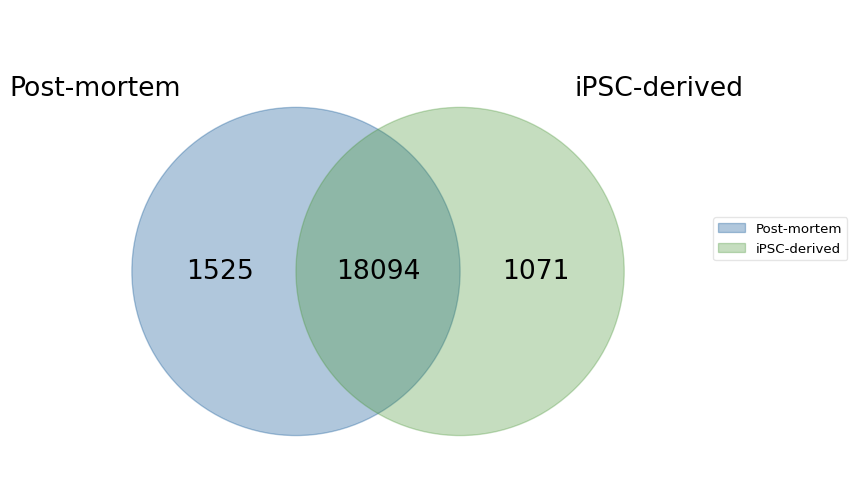

In [9]:
#mpl.use('Agg')
import sys
sys.path.insert(1, '/home/anna/Downloads/pyvenn/')
import venn
plt.figure(figsize=(3,3))
labels = venn.get_labels([set(x1),set(x2)], fill=['number'])
venn.venn2(labels, names=['Post-mortem','iPSC-derived'],fontsize=20,colors=['#034e9150','#46943350'],alpha=0.5)
plt.tight_layout()
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/venn_fires.pdf')




In [31]:
en=w_tmp[['chrom','end','group']].groupby('group').max().reset_index()

new_fires=w_tmp[['chrom','start','group']].groupby('group').min().reset_index()

new_fires['end']=list(en.end)

new_fires=new_fires[['chrom','start','end']]

In [47]:
neu_ids=a.loc[(a['adj.P.Val']<0.05)&(a['logFC']>0)].index
cult_ids=a.loc[(a['adj.P.Val']<0.05)&(a['logFC']<0)].index

In [50]:
cult_spec=new_fires.loc[cult_ids]
neu_spec=new_fires.loc[neu_ids]

cult_spec_bed=pybedtools.BedTool.from_dataframe(cult_spec)
neu_spec_bed=pybedtools.BedTool.from_dataframe(neu_spec)

cult_genes=g_bed.intersect(cult_spec_bed).to_dataframe()
neu_genes=g_bed.intersect(neu_spec_bed).to_dataframe()

In [51]:
not_cult_spec=new_fires.loc[~new_fires.index.isin(cult_ids)]
not_neu_spec=new_fires.loc[~new_fires.index.isin(neu_ids)]

In [52]:
new_fires_bed=pybedtools.BedTool.from_dataframe(new_fires)
all_genes_in_fires=g_bed.intersect(new_fires_bed).to_dataframe()

In [174]:
all_genes_in_fires[['name']].to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/genes_in_union_of_fires_with_heffel_inf.txt',sep='\t',header=None,index=None)

In [181]:
neu_genes[['name']].to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/neu_spec_fires_genes_with_Hef_inf.txt',sep='\t',header=None,index=None)

In [455]:
####################################

In [366]:
c=cooler.Cooler('/home/anna/anna_data/Autism/SCZ_new_data/HC_3M_91_SZ_01_03_plus_drop_diag_5K.cool')

chrom_dict={}
for i in range(len(c.chromsizes)):
    chrom_dict[c.chromsizes.index[i]]=c.chromsizes[i]




def pylap_new(path_to_points,path_to_data,nbins,chrs,res,chrom_dict):
    #Q=0
    points=pd.read_csv(path_to_points,sep='\t',header=None)
    chr_length=chrom_dict
    
    points.columns=['chrom','start','end']

    for i in list(chr_length.keys()):

        points=points.drop(points[(points['chrom']==i) & (points['start']>chr_length[i]-nbins*res)].index)

    h=points[points['start']>=nbins*res]
    h.sort_values(['chrom','start'],inplace=True)

    points=pybedtools.BedTool.from_dataframe(h)
    path=pd.read_csv(path_to_data,sep='\t',header=None)
    data=pybedtools.BedTool.from_dataframe(path)
    t=data.intersect(points,wao=True).to_dataframe()

    t= t.loc[t['chrom'].isin(chrs)]
    t.loc[t.name=='.','name']=np.nan
    q=sum(t['strand']!=-1)

    n=np.zeros((q,2*nbins+1))
    k=0
    for i in chrs:
       
        tmp=t[t['chrom']==i]
       
        tmp=tmp.reset_index(drop=True)
        for j in range(len(tmp)):

            if tmp.loc[j]['strand']!=-1:
                print(tmp.loc[j-nbins:j+nbins]['name'])
                n[k]=tmp.loc[j-nbins:j+nbins]['name']
                
                k+=1
            
    A=pd.DataFrame(n)
    return(A)



def plott(xx,lab,m,colo,alp,legend):
    l=[]
    u=[]
    for i in xx.columns:
        a=xx[i]
        a=a[~np.isnan(a)]
        x=np.mean(a)-1.961*np.std(a)/np.sqrt(len(a))
        y=np.mean(a)+1.961*np.std(a)/np.sqrt(len(a))
        l.append(x)
        u.append(y)
    xfit = np.linspace(0,2*m, 100) 
    
    spl = scipy.interpolate.make_interp_spline(np.arange(2*m+1),np.nanmean(xx,axis=0), k=3) 
    yfit = spl(xfit)
    spl = scipy.interpolate.make_interp_spline(np.arange(2*m+1),l, k=3) 
    fit_l = spl(xfit)

    spl = scipy.interpolate.make_interp_spline(np.arange(2*m+1),u, k=3) 
    fit_u = spl(xfit)
    
    plt.plot(xfit,yfit, '-',label=lab,c=colo)#

    plt.fill_between(xfit, fit_l, fit_u,
                 color=colo, alpha=alp)
    if legend==True:
        plt.legend(bbox_to_anchor=(1.55, 1),loc='upper right')




In [41]:
#################################################################################333

In [186]:
enh=pd.read_excel('/home/anna/Downloads/NIHMS1832751-supplement-1832751_Sup_tables.xlsx',sheet_name='Supplementary Tables 5')

enh1=enh.enhancer.str.split('_',expand=True)
enh1=enh1.loc[enh1[0]!='glia']

enh_bed=pybedtools.BedTool.from_dataframe(enh1[[0,1,2]])

In [188]:
cult_spec=pybedtools.BedTool('/media/anna/Samsung_T5/culture_vs_postmortem/cult_spec_super_fires_with_hef_inf.bed')

In [189]:
df=cult_spec.intersect(enh_bed,wa=True).to_dataframe()

In [190]:
df.drop_duplicates(inplace=True)

In [191]:
len(df)

84

In [217]:
df=not_cult_spec_bed.intersect(enh_bed,wa=True).to_dataframe()

df.drop_duplicates(inplace=True)

len(df)

3412

In [192]:
neu_spec=pybedtools.BedTool('/media/anna/Samsung_T5/culture_vs_postmortem/neu_spec_super_fires_with_hef_inf.bed')

df=neu_spec.intersect(enh_bed,wa=True).to_dataframe()

In [193]:
df.drop_duplicates(inplace=True)

len(df)

473

In [215]:
df=not_neu_spec_bed.intersect(enh_bed,wa=True).to_dataframe()

In [216]:
df.drop_duplicates(inplace=True)

len(df)

3023

In [169]:
gh=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/GeneHancer_AnnotSV_elements_v5.18.txt',sep='\t')

/tmp/ipykernel_19685/2219013974.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gh=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/GeneHancer_AnnotSV_elements_v5.18.txt',sep='\t')


In [170]:
ns=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/GeneHancer_AnnotSV_tissues_v5.18.txt',sep='\t')

/tmp/ipykernel_19685/1494284418.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  ns=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/GeneHancer_AnnotSV_tissues_v5.18.txt',sep='\t')


In [176]:
gh=gh.loc[gh.GHid.isin(ns.loc[ns.tissue=='neural stem progenitor cell','GHid'])]

In [177]:
gh.chr='chr'+gh.chr.astype(str)

In [178]:
gh_bed=pybedtools.BedTool.from_dataframe(gh[['chr','element_start','element_end']])

In [200]:
dh=cult_spec_bed.intersect(gh_bed,wa=True).to_dataframe()
dh.drop_duplicates(inplace=True)
len(dh)

403

In [218]:
dh=not_cult_spec_bed.intersect(gh_bed,wa=True).to_dataframe()
dh.drop_duplicates(inplace=True)
len(dh)

4728

In [195]:
dh=neu_spec_bed.intersect(gh_bed,wa=True).to_dataframe()
dh.drop_duplicates(inplace=True)
len(dh)

340

In [219]:
dh=not_neu_spec_bed.intersect(gh_bed,wa=True).to_dataframe()
dh.drop_duplicates(inplace=True)
len(dh)

4791

In [182]:
cu=cult_spec_bed.to_dataframe()

In [183]:
np.sum(cu.end-cu.start)/10000

2176.0

In [184]:
ne=neu_spec_bed.to_dataframe()

np.sum(ne.end-ne.start)/10000

3958.0

In [220]:
scipy.stats.chi2_contingency([[84,403],[3412,4728]])

(114.99204704450966,
 7.9013712167811e-27,
 1,
 array([[ 197.35157065,  289.64842935],
        [3298.64842935, 4841.35157065]]))

In [221]:
scipy.stats.chi2_contingency([[473,340],[3023,4791]])

(115.28144543851424,
 6.828474515674608e-27,
 1,
 array([[ 329.45960357,  483.54039643],
        [3166.54039643, 4647.45960357]]))

In [204]:
scipy.stats.chi2_contingency([[233,1792-233],[17,574-17]])

(45.32294455408704,
 1.6708021629097572e-11,
 1,
 array([[ 189.34911243, 1602.65088757],
        [  60.65088757,  513.34911243]]))

In [161]:
scipy.stats.chi2_contingency([[123,574-123],[171,1792-171]])

(55.35609066216559,
 1.0055780463090744e-13,
 1,
 array([[  71.32544379,  502.67455621],
        [ 222.67455621, 1569.32544379]]))

In [162]:
233/1792

0.13002232142857142

In [167]:
123/574

0.21428571428571427

In [168]:
171/1792

0.09542410714285714

In [153]:
84/(np.sum(cu.end-cu.start)/10000)

0.03860294117647059

In [154]:
473/(np.sum(ne.end-ne.start)/10000)

0.11950480040424456

In [155]:
403/(np.sum(cu.end-cu.start)/10000)

0.18520220588235295

In [156]:
340/(np.sum(ne.end-ne.start)/10000)

0.08590197069226882

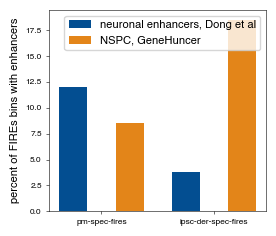

In [166]:
plt.figure(figsize=(2.8,2.4))
plt.bar(height=12,x=0,width=0.5,color=pm,label='neuronal enhancers, Dong et al')
#plt.bar(height=1-0.13,x=0,width=0.5,bottom=0.13,color='grey',label=)
plt.bar(height=8.5,x=1,width=0.5,color=npc,label='NSPC, GeneHuncer')
plt.bar(height=3.8,x=2,width=0.5,bottom=0.03,color=pm)
plt.bar(height=18.5,x=3,width=0.5,bottom=0.03,color=npc)
plt.ylabel('percent of FIREs bins with enhancers',fontsize=8)
plt.legend()
plt.xticks([0.5,2.5],['pm-spec-fires','ipsc-der-spec-fires'])
plt.tight_layout()
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/enhancers_in_FIREs_with_heffel_inf.pdf')

In [28]:
################### FIREs intersection ##########################

In [3]:
os.listdir('/media/anna/Samsung_T5/culture_vs_postmortem/')
files=['FIRE_ANALYSIS_10000_200000_poisson_Eres_iPSC.txt',
       'FIRE_ANALYSIS_10000_200000_poisson_Artrial_iPSC.txt',
    'FIRE_ANALYSIS_10000_200000_poisson_Ballarino_NPC.txt',                                                 
 'FIRE_ANALYSIS_10000_200000_poisson_Rajarajan_NPC.txt',                                                   
 'FIRE_ANALYSIS_10000_200000_poisson_Zaghi_NPC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Plet_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahm_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Hu.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Tian.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_adult.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_infant.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_2T.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_3T.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahman_fetal.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Wu2021_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Li_unbalaced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_PsychENC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Ballerino.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Zaghi.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahman_iPSC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Lagar.txt',
 ]

labs=[]
for f in files:
    
    x_tmp=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/%s'%f,sep=' ')
    x_tmp['lab']=x_tmp.chr+':'+x_tmp.start.astype(str)+':'+x_tmp.end.astype(str)
    labs.append(list(x_tmp.lab))



lab=labs[0]    
for i in range(1,len(labs)):
    lab=list(set(lab)&set(labs[i]))



w=pd.DataFrame()
for f in files:
    n=f.split('FIRE_ANALYSIS_10000_200000_poisson_')[1].split('.txt')[0]
    x_tmp=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/%s'%f,sep=' ')
    x_tmp['lab']=x_tmp.chr+':'+x_tmp.start.astype(str)+':'+x_tmp.end.astype(str)
    labs.append(x_tmp.lab)
    x_tmp=x_tmp.loc[x_tmp.lab.isin(lab)].sort_values(['chr','start']).reset_index(drop=True)
    w[n]=x_tmp[x_tmp.columns[5]]


In [4]:
os.listdir('/media/anna/Samsung_T5/culture_vs_postmortem/')
files=['FIRE_ANALYSIS_10000_200000_poisson_Eres_iPSC.txt',
       'FIRE_ANALYSIS_10000_200000_poisson_Artrial_iPSC.txt',
    'FIRE_ANALYSIS_10000_200000_poisson_Ballarino_NPC.txt',                                                 
 'FIRE_ANALYSIS_10000_200000_poisson_Rajarajan_NPC.txt',                                                   
 'FIRE_ANALYSIS_10000_200000_poisson_Zaghi_NPC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Plet_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahm_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Hu.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Tian.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_adult.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_infant.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_2T.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Heffel_3T.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahman_fetal.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Wu2021_unbalanced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Li_unbalaced.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_PsychENC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Ballerino.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Zaghi.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Rahman_iPSC.txt',
 'FIRE_ANALYSIS_10000_200000_poisson_Lagar.txt',
 ]

labs=[]
for f in files:
    
    x_tmp=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/%s'%f,sep=' ')
    x_tmp['lab']=x_tmp.chr+':'+x_tmp.start.astype(str)+':'+x_tmp.end.astype(str)
    labs.append(list(x_tmp.lab))



lab=labs[0]    
for i in range(1,len(labs)):
    lab=list(set(lab)&set(labs[i]))



v=pd.DataFrame()
for f in files:
    n=f.split('FIRE_ANALYSIS_10000_200000_poisson_')[1].split('.txt')[0]
    x_tmp=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/%s'%f,sep=' ')
    x_tmp['lab']=x_tmp.chr+':'+x_tmp.start.astype(str)+':'+x_tmp.end.astype(str)
    labs.append(x_tmp.lab)
    x_tmp=x_tmp.loc[x_tmp.lab.isin(lab)].sort_values(['chr','start']).reset_index(drop=True)
    v[n]=x_tmp[x_tmp.columns[3]]


In [5]:
stem_cell=w[['Eres_iPSC', 'Artrial_iPSC']]
post_mort=w[['Plet_unbalanced', 'Rahm_unbalanced', 'Hu', 'Tian',
       'Heffel_adult', 'Heffel_infant']]
NPC=w[['Ballarino_NPC', 'Rajarajan_NPC',
       'Zaghi_NPC']]
fetal=w[['Heffel_2T', 'Heffel_3T','Rahman_fetal']]
iPSC_der=w[['Wu2021_unbalanced', 'Li_unbalaced', 'PsychENC',
       'Ballerino', 'Zaghi', 'Rahman_iPSC', 'Lagar']]

In [6]:
stem_cell_sig=v[['Eres_iPSC', 'Artrial_iPSC']]
post_mort_sig=v[['Plet_unbalanced', 'Rahm_unbalanced', 'Hu', 'Tian',
       'Heffel_adult', 'Heffel_infant']]
NPC_sig=v[['Ballarino_NPC', 'Rajarajan_NPC',
       'Zaghi_NPC']]
fetal_sig=v[['Heffel_2T', 'Heffel_3T','Rahman_fetal']]
iPSC_der_sig=v[['Wu2021_unbalanced', 'Li_unbalaced', 'PsychENC',
       'Ballerino', 'Zaghi', 'Rahman_iPSC', 'Lagar']]

In [10]:
res=[]
names=[]
cells=[stem_cell,NPC,fetal,post_mort]
signal=[stem_cell_sig,NPC_sig,fetal_sig,post_mort_sig]
for x in range(len(cells)):
    res_tmp=[]
    names_tmp=[]
    y=cells[x]
    sig=signal[x]
    for j in y.columns:
        for k in iPSC_der.columns:
            ids_ipsc_der=iPSC_der.loc[iPSC_der[k]==1].index
            ids_x=y.loc[y[j]==1].index
            rest=set(ids_x)-set(ids_ipsc_der)
            ipsc_df=sig.loc[ids_ipsc_der]
            rest_f=sig.loc[rest]
            ratio=np.nanmedian(ipsc_df)/np.nanmedian(rest_f)
            res_tmp.append(ratio)
            names_tmp.append(j+':'+k)
            if ((j=='Ballarino_NPC')&(k=='Ballerino'))|((j=='Zaghi_NPC')&(k=='Zaghi'))|((j=='Rajarajan_NPC')&(k=='PsychENC')):
                print(ratio,j)
    res.append(res_tmp)
    names.append(names_tmp)

/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a fut

1.02186889602611 Ballarino_NPC
0.9533161600602733 Rajarajan_NPC
1.0159554204970673 Zaghi_NPC


/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_f=sig.loc[rest]
/tmp/ipykernel_981933/3495512794.py:16: FutureWarning: Passing a set as an indexer is deprecated and will raise in a fut

In [11]:
ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='#e38519'
sc='#696969'

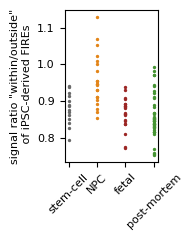

In [59]:
plt.figure(figsize=(2,2.5))
cols=[sc,npc,fet,ipsc]
for i in range(len(res)):
    plt.scatter([i]*len(res[i]),res[i],c=cols[i],s=2)
plt.xticks([0,1,2,3],['stem-cell','NPC','fetal','post-mortem'],fontsize=8,rotation=45)
#plt.xticks([0,1,2,3],['stem-cell','NPC','fetal','iPSC-derived'],fontsize=8,rotation=45)
plt.ylabel('signal ratio "within/outside"\n of iPSC-derived FIREs',fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/FIREs_intersections_with_PM_signal_ratios.pdf')

In [61]:
for i in range(len(res)):
    print(scipy.stats.mannwhitneyu(res[i],res[1]))

MannwhitneyuResult(statistic=46.0, pvalue=0.0007143513483707082)
MannwhitneyuResult(statistic=220.5, pvalue=1.0)
MannwhitneyuResult(statistic=52.0, pvalue=2.3770840583993122e-05)
MannwhitneyuResult(statistic=109.0, pvalue=1.3424219865141344e-06)


In [336]:
###############table with histone tracks#####################

In [418]:
a1=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/histone_track_table.txt',sep='\t')

In [425]:
a2=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/histone_track_table_Choi_Titus_10K.txt',sep='\t')

In [434]:
a=pd.concat([a1,a2[a2.columns[3:]]],axis=1)

In [437]:
a=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/histone_track_table_10K.txt.gz',sep='\t')

In [438]:
signal=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27ac/new_scale/H3K27ac_Zaghi_NPC_10K_new_scale.bedgraph',sep='\t',header=None)
inputs=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27ac/new_scale/IgG_Zaghi_NPC_10K_new_scale.bedgraph',sep='\t',header=None)

In [440]:
a['H3K27ac_Zaghi_NPC']=signal[3]
a['IgG_Zaghi_NPC']=inputs[3]

In [442]:
a.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/histone_track_table_10K.txt.gz',sep='\t',index=None)

In [443]:
a.columns

Index(['0', '1', '2', 'MSSM_PFC_1377', 'MSSM_PFC_1377_IN', 'MSSM_PFC_1423',
       'MSSM_PFC_1423_IN', 'Wu_input_rep1', 'Li_input_rep1', 'Wu_rep1',
       'Li_rep1', 'MSSM_PFC_1275', 'MSSM_PFC_1275_IN', 'H3K27ac_D53',
       'H3K27ac_NPC', 'H3K27ac_fetal', 'H3K27me3_D53', 'H3K27me3_NPC',
       'H3K4me1_fetal', 'H3K4me3_D53', 'H3K4me3_NPC', 'H3K4me3_fetal',
       'H3K9me3_D53', 'H3K9me3_NPC', 'IgG_D53', 'IgG_NPC', 'IgG_fetal',
       'Choi_NPC_H3K27ac', 'Choi_NPC_H3K4me3', 'Choi_NPC_input',
       'Choi_iPSC_H3K27ac', 'Choi_iPSC_H3K4me3', 'Choi_iPSC_input',
       'Titus_NPC_H3K27ac', 'Titus_NPC_H3K27ac_input', 'Titus_iPSC_H3K27ac',
       'Titus_iPSC_H3K27ac_input', 'H3K27ac_Zaghi_NPC', 'IgG_Zaghi_NPC'],
      dtype='object')

In [444]:
signal=['MSSM_PFC_1377','MSSM_PFC_1423','MSSM_PFC_1275', 
       'Li_rep1', 'H3K27ac_D53','Wu_rep1',
       'H3K27ac_NPC', 'Choi_NPC_H3K27ac','Titus_NPC_H3K27ac','H3K27ac_Zaghi_NPC',
       'Choi_iPSC_H3K27ac','Titus_iPSC_H3K27ac']

In [445]:
inputs=['MSSM_PFC_1377_IN','MSSM_PFC_1423_IN', 'MSSM_PFC_1275_IN',
      'Li_input_rep1', 'IgG_D53',  'Wu_input_rep1', 
      'IgG_NPC','Choi_NPC_input', 'Titus_NPC_H3K27ac_input','IgG_Zaghi_NPC',
       'Choi_iPSC_input','Titus_iPSC_H3K27ac_input']

In [459]:
normal=a[['0', '1', '2']].copy()
for i in range(len(signal)):
    minn=np.array(a[[signal[i],inputs[i]]]).flatten()
    minn=minn[~np.isnan(minn)]
    minn=minn[minn>0]
    minim=np.percentile(minn,[1])[0]
    normal[signal[i]]=(a[signal[i]]+minim)/(a[inputs[i]]+minim)

In [462]:
normal.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/histone_track_H3K27ac_normalized_table_10K.txt.gz',sep='\t',index=None)

In [148]:
b.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/histone_normalized_track_table.txt',sep='\t',index=None)

In [149]:
b.columns=['chrom','start','end', 'MSSM_PFC_1377_norm', 'MSSM_PFC_1423_norm',
       'MSSM_PFC_1275_norm', 'Wu_rep1_norm', 'Li_rep1_norm',
       'H3K27ac_D53_norm', 'H3K27me3_D53_norm', 'H3K4me3_D53_norm',
       'H3K9me3_D53_norm', 'H3K27ac_NPC_norm', 'H3K27me3_NPC_norm',
       'H3K4me3_NPC_norm', 'H3K9me3_NPC_norm', 'H3K27ac_fetal_norm',
       'H3K4me1_fetal_norm', 'H3K4me3_fetal_norm']

In [150]:
b['H3K27ac_pm']=np.nanmean(b[['MSSM_PFC_1377_norm', 'MSSM_PFC_1423_norm', 'MSSM_PFC_1275_norm']],axis=1)

/tmp/ipykernel_10659/2847936461.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['H3K27ac_pm']=np.nanmean(b[['MSSM_PFC_1377_norm', 'MSSM_PFC_1423_norm', 'MSSM_PFC_1275_norm']],axis=1)


In [151]:
b['H3K27ac_iPSCder']=np.nanmean(b[['Wu_rep1_norm', 'Li_rep1_norm', 'H3K27ac_D53_norm']],axis=1)

/tmp/ipykernel_10659/1755389610.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['H3K27ac_iPSCder']=np.nanmean(b[['Wu_rep1_norm', 'Li_rep1_norm', 'H3K27ac_D53_norm']],axis=1)


In [406]:
b[['chrom','start','end','H3K27ac_pm', 'H3K27ac_iPSCder','H3K27ac_fetal_norm','H3K27ac_NPC_norm','H3K27ac_NPC_Zaghi_norm']].to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/epi_tracks/H3K27ac.txt',sep='\t',index=None)

In [153]:
######################################

In [20]:
normal=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/histone_track_H3K27ac_normalized_table_10K.txt.gz',sep='\t')

In [22]:
peak_path='/media/anna/Samsung_T5/culture_vs_postmortem/H3K27ac/H3K4me3_peaks/'
peaks=['MSSM_PFC_1377_peaks.narrowPeak',
       'MSSM_PFC_1423_peaks.narrowPeak',
       'MSSM_PFC_1275_peaks.narrowPeak',
       'WuH3K4me3_rep1_peaks.narrowPeak',
       'CnR_H3K4me3_D53_REP1_peaks.narrowPeak', 
       'WuH3K4me3_rep1_peaks.narrowPeak',
       'Choi_NPC_H3K4me3_REP1_peaks.narrowPeak',
       'Choi_NPC_H3K4me3_REP1_peaks.narrowPeak',
       'Choi_NPC_H3K4me3_REP1_peaks.narrowPeak',
       'Choi_iPSC_H3K4me3_REP1_peaks.narrowPeak',
       'Choi_iPSC_H3K4me3_REP1_peaks.narrowPeak']

k=0
dh=pd.DataFrame()
for i in ['MSSM_PFC_1377', 'MSSM_PFC_1423', 'MSSM_PFC_1275','Li_rep1', 'H3K27ac_D53', 'Wu_rep1', 
          'Choi_NPC_H3K27ac','Titus_NPC_H3K27ac', 'H3K27ac_Zaghi_NPC',
          'Choi_iPSC_H3K27ac','Titus_iPSC_H3K27ac']:
    
    peak_tmp=pd.read_csv(peak_path+peaks[k],sep='\t',header=None)
    peak_tmp=pybedtools.BedTool.from_dataframe(peak_tmp[[0,1,2]])
    track_tmp=pybedtools.BedTool.from_dataframe(normal[['0','1','2',i]])
    track_tmp=track_tmp.intersect(peak_tmp,wao=True).to_dataframe()
    track_tmp=track_tmp.groupby(['chrom','start','end']).sum().reset_index()
    track_tmp.loc[track_tmp.thickEnd/(track_tmp.end-track_tmp.start)>0.1,'name']=np.nan
    dh[i]=track_tmp['name']
dh=pd.concat([track_tmp[['chrom','start','end']],dh],axis=1)

/tmp/ipykernel_287131/454350714.py:24: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  track_tmp=track_tmp.groupby(['chrom','start','end']).sum().reset_index()
/tmp/ipykernel_287131/454350714.py:24: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  track_tmp=track_tmp.groupby(['chrom','start','end']).sum().reset_index()
/tmp/ipykernel_287131/454350714.py:24: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  track_tmp=track_tmp.gro

In [26]:
for i in dh.columns[3:]:
    dh[['chrom','start','end',i]].to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/epi_tracks/%s_norm_drop_H3K4me3.txt'%i,sep='\t',index=None)

In [514]:
dh['H3K27ac_post_mort']=dh[['MSSM_PFC_1377', 'MSSM_PFC_1423','MSSM_PFC_1275']].mean(axis=1)
dh['H3K27ac_iPSC_derived']=dh[['Li_rep1', 'H3K27ac_D53', 'Wu_rep1']].mean(axis=1)
dh['H3K27ac_NPC']=dh[['Choi_NPC_H3K27ac', 'Titus_NPC_H3K27ac', 'H3K27ac_Zaghi_NPC']].mean(axis=1)
dh['H3K27ac_iPSC']=dh[['Choi_iPSC_H3K27ac', 'Titus_iPSC_H3K27ac']].mean(axis=1)

In [519]:
dh[['chrom', 'start', 'end','H3K27ac_iPSC']].to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/epi_tracks/H3K27ac_iPSC_norm_drop_H3K4me3.txt',sep='\t',header=None,index=None)

In [32]:
path='/media/anna/Samsung_T5/culture_vs_postmortem/epi_tracks/'
files=['H3K27ac_post_mort_norm_drop_H3K4me3.txt','H3K27ac_iPSC_derived_norm_drop_H3K4me3.txt', 
       'H3K27ac_NPC_norm_drop_H3K4me3.txt', 'H3K27ac_iPSC_norm_drop_H3K4me3.txt']

c=pd.read_csv(path+files[0],sep='\t',header=None)
chroms=list(c[0].value_counts().index)
d={}
for f in files:
    pn=pylap_new('/media/anna/Samsung_T5/culture_vs_postmortem/cult_spec_super_fires_center_with_hef_inf.bed',
             path+f,6,chroms,10000,chrom_dict)
    for i in range(len(pn)):
        pn.loc[i]=pn.loc[i]-pn.loc[i][list(np.arange(0,4))+list(np.arange(9,13))].mean()
    d[f]=pn


d_neu={}
for f in files:
    pn=pylap_new('/media/anna/Samsung_T5/culture_vs_postmortem/neu_spec_super_fires_center_with_hef_inf.bed',
             path+f,6,chroms,10000,chrom_dict)
    for i in range(len(pn)):
        pn.loc[i]=pn.loc[i]-pn.loc[i][list(np.arange(0,4))+list(np.arange(9,13))].mean()
    d_neu[f]=pn



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

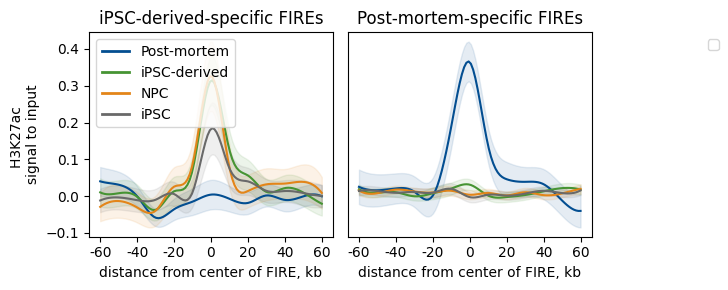

In [33]:
ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='#e38519'
sc='#696969'
        
labels=['Post-mortem','iPSC-derived','NPC','iPSC']
fig=plt.figure(figsize=(7.5,3))
fig.add_subplot(1,2,1)

plott(x,'',6,pm,0.1,legend=True)
x=d['H3K27ac_iPSC_derived_norm_drop_H3K4me3.txt']
plott(x,'',6,ipsc,0.1,legend=True)
x=d['H3K27ac_NPC_norm_drop_H3K4me3.txt']
plott(x,'',6,npc,0.1,legend=True)
x=d['H3K27ac_iPSC_norm_drop_H3K4me3.txt']
plott(x,'',6,sc,0.1,legend=True)


plt.xticks(np.arange(0,13,2),np.arange(-6,7,2)*10)
plt.xlabel('distance from center of FIRE, kb')
plt.ylabel('H3K27ac \nsignal to input')
plt.title('iPSC-derived-specific FIREs')

legend_elements = [Line2D([0], [0], lw=2, color=pm, label=labels[0]),
                   Line2D([0], [0], lw=2, color=ipsc, label=labels[1]),
                  Line2D([0], [0], lw=2, color=npc, label=labels[2]),
                   Line2D([0], [0], lw=2, color=sc, label=labels[3])]


plt.legend(handles= legend_elements,loc='upper left')

fig.add_subplot(1,2,2)

x=d_neu['H3K27ac_post_mort_norm_drop_H3K4me3.txt']
plott(x,'',6,pm,0.1,legend=True)
x=d_neu['H3K27ac_iPSC_derived_norm_drop_H3K4me3.txt']
plott(x,'',6,ipsc,0.1,legend=True)
x=d_neu['H3K27ac_NPC_norm_drop_H3K4me3.txt']
plott(x,'',6,npc,0.1,legend=True)
x=d_neu['H3K27ac_iPSC_norm_drop_H3K4me3.txt']
plott(x,'',6,sc,0.1,legend=True)

plt.xticks(np.arange(0,13,2),np.arange(-6,7,2)*10)
plt.xlabel('distance from center of FIRE, kb')
plt.ylabel('')
plt.yticks([])
plt.title('Post-mortem-specific FIREs')
plt.tight_layout()


#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27ac_signal_in_spec_four_types_merged_with_hef_inf.pdf')

In [35]:
scipy.stats.wilcoxon(d['H3K27ac_iPSC_derived_norm_drop_H3K4me3.txt'][6],d["H3K27ac_post_mort_norm_drop_H3K4me3.txt"][6])

WilcoxonResult(statistic=228078.0, pvalue=1.6786845246965278e-52)

In [4]:
## применение функций
path='/media/anna/Samsung_T5/culture_vs_postmortem/epi_tracks/'
files=['MSSM_PFC_1377_norm.txt', 'MSSM_PFC_1423_norm.txt', 'MSSM_PFC_1275_norm.txt',
       'Li_rep1_norm.txt', 'H3K27ac_D53_norm.txt', 'Wu_rep1_norm.txt', 'H3K27ac_NPC_norm.txt', 'Choi_NPC_H3K27ac_norm.txt',
       'Titus_NPC_H3K27ac_norm.txt', 'H3K27ac_Zaghi_NPC_norm.txt', 'Choi_iPSC_H3K27ac_norm.txt',
       'Titus_iPSC_H3K27ac_norm.txt']

c=pd.read_csv(path+files[0],sep='\t',header=None)
chroms=list(c[0].value_counts().index)
d={}
for f in files:
    pn=pylap_new('/media/anna/Samsung_T5/culture_vs_postmortem/cult_spec_super_fires_center.bed',
             path+f,6,chroms,10000,chrom_dict)
    #for i in range(len(pn)):
        #pn.loc[i]=pn.loc[i]-pn.loc[list(np.arange(0,4))+list(np.arange(9,13))].mean()
    d[f]=pn


d_neu={}
for f in files:
    pn=pylap_new('/media/anna/Samsung_T5/culture_vs_postmortem/neu_spec_super_fires_center.bed',
             path+f,6,chroms,10000,chrom_dict)
    #for i in range(len(pn)):
        #pn.loc[i]=pn.loc[i]-pn.loc[list(np.arange(0,4))+list(np.arange(9,13))].mean()
    d_neu[f]=pn



In [6]:
## применение функций
path='/media/anna/Samsung_T5/culture_vs_postmortem/epi_tracks/'
files=['MSSM_PFC_1377_norm_drop_H3K4me3.txt', 'MSSM_PFC_1423_norm_drop_H3K4me3.txt', 'MSSM_PFC_1275_norm_drop_H3K4me3.txt',
       'Li_rep1_norm_drop_H3K4me3.txt', 'H3K27ac_D53_norm_drop_H3K4me3.txt', 'Wu_rep1_norm_drop_H3K4me3.txt',  
       'Choi_NPC_H3K27ac_norm_drop_H3K4me3.txt','Titus_NPC_H3K27ac_norm_drop_H3K4me3.txt', 'H3K27ac_Zaghi_NPC_norm_drop_H3K4me3.txt', 'Choi_iPSC_H3K27ac_norm_drop_H3K4me3.txt',
       'Titus_iPSC_H3K27ac_norm_drop_H3K4me3.txt']

c=pd.read_csv(path+files[0],sep='\t',header=None)
chroms=list(c[0].value_counts().index)
d={}
for f in files:
    pn=pylap_new('/media/anna/Samsung_T5/culture_vs_postmortem/cult_spec_super_fires_center_with_hef_inf.bed',
             path+f,6,chroms,10000,chrom_dict)
    #for i in range(len(pn)):
        #pn.loc[i]=pn.loc[i]-pn.loc[list(np.arange(0,4))+list(np.arange(9,13))].mean()
    d[f]=pn


d_neu={}
for f in files:
    pn=pylap_new('/media/anna/Samsung_T5/culture_vs_postmortem/neu_spec_super_fires_center_with_hef_inf.bed',
             path+f,6,chroms,10000,chrom_dict)
    #for i in range(len(pn)):
        #pn.loc[i]=pn.loc[i]-pn.loc[list(np.arange(0,4))+list(np.arange(9,13))].mean()
    d_neu[f]=pn



/tmp/ipykernel_70536/1056496426.py:8: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  c=pd.read_csv(path+files[0],sep='\t',header=None)
/tmp/ipykernel_70536/3376528250.py:29: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  path=pd.read_csv(path_to_data,sep='\t',header=None)
/tmp/ipykernel_70536/3376528250.py:29: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  path=pd.read_csv(path_to_data,sep='\t',header=None)
/tmp/ipykernel_70536/3376528250.py:29: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  path=pd.read_csv(path_to_data,sep='\t',header=None)
/tmp/ipykernel_70536/3376528250.py:29: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  path=pd.read_csv(path_to_data,sep='\t',header=None)
/tmp/ipykernel_705

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

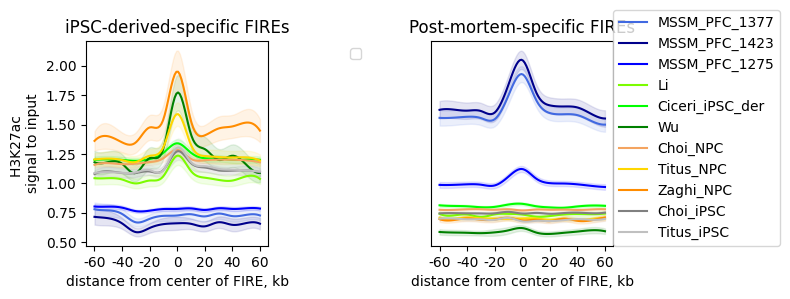

In [8]:
ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='#e38519'
sc='#696969'

labels=['MSSM_PFC_1377', 'MSSM_PFC_1423', 'MSSM_PFC_1275',
       'Li', 'Ciceri_iPSC_der', 'Wu',  'Choi_NPC',
       'Titus_NPC', 'Zaghi_NPC', 'Choi_iPSC','Titus_iPSC']
fig=plt.figure(figsize=(8,3))
fig.add_subplot(1,2,1)

names=['MSSM_PFC_1377_norm_drop_H3K4me3.txt', 'MSSM_PFC_1423_norm_drop_H3K4me3.txt', 'MSSM_PFC_1275_norm_drop_H3K4me3.txt',
       'Li_rep1_norm_drop_H3K4me3.txt', 'H3K27ac_D53_norm_drop_H3K4me3.txt', 'Wu_rep1_norm_drop_H3K4me3.txt',
        'Choi_NPC_H3K27ac_norm_drop_H3K4me3.txt',
       'Titus_NPC_H3K27ac_norm_drop_H3K4me3.txt',
       'H3K27ac_Zaghi_NPC_norm_drop_H3K4me3.txt', 'Choi_iPSC_H3K27ac_norm_drop_H3K4me3.txt',
       'Titus_iPSC_H3K27ac_norm_drop_H3K4me3.txt']

cols=['royalblue','darkblue','blue','lawngreen','lime','green','sandybrown','gold','darkorange',
      'grey','silver']
#cols=sns.color_palette("Paired", len(names))

for i in range(len(names)):
    x=d[names[i]]
    plott(x,'',6,cols[i],0.1,legend=True)

plt.xticks(np.arange(0,13,2),np.arange(-6,7,2)*10)
plt.xlabel('distance from center of FIRE, kb')
plt.ylabel('H3K27ac \nsignal to input')
plt.title('iPSC-derived-specific FIREs')



fig.add_subplot(1,2,2)

for i in range(len(names)):
    x=d_neu[names[i]]
    plott(x,labels[i],6,cols[i],0.1,legend=True)
    
plt.legend(loc=(1,0))
plt.xticks(np.arange(0,13,2),np.arange(-6,7,2)*10)
plt.xlabel('distance from center of FIRE, kb')
plt.ylabel('')
plt.yticks([])
plt.title('Post-mortem-specific FIREs')
plt.tight_layout()

#y, h, col = 0.4, 0.2, 'k'
#x1, x2 = 6,6.25
#plt.plot([x1, x2, x2,x1], [y, y, y-h,y-h], lw=0.5, c=col)
#plt.text((x1+x2)*.5, y+h, "****", ha='center', va='bottom', color=col)


plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27ac_signal_by_samples_drop_H3K4me3_hef_inf.pdf')

In [ ]:
########################

In [63]:
expr=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/rlog_protein_coding_cortex_all_blind_true.txt',sep='\t',index_col=0)

expr['pm']=np.nanmean(expr[['acc_rous', 'dlpfc_rous', 'riz']],axis=1)
expr['iPSCder']=np.nanmean(expr[['Li_iPSCder', 'Lu_iPSCder','PRJNA_iPSCder', 'Zaghi_iPSCder', 'Ciceri50_iPSCder']],axis=1)
expr['iPSC']=np.nanmean(expr[['Flamier_iPSC','Lu_iPSC']],axis=1)
expr['NPC']=np.nanmean(expr[['Topol_NPC', 'Lu_NPC']],axis=1)

expr=expr[['iPSC', 'NPC', 'iPSCder','pm']]

In [88]:
cult_ids=set(expr.index)&set(cult_genes.name)
cult_fires_expr=expr.loc[cult_ids]


/tmp/ipykernel_287131/2176953893.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  cult_fires_expr=expr.loc[cult_ids]


/tmp/ipykernel_287131/3567308019.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  cult_fires_expr=expr.loc[cult_ids]
/tmp/ipykernel_287131/3567308019.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a=sns.boxplot(data=my_df,x="samples", y='transcription, rlog',palette=pal,
/tmp/ipykernel_287131/3567308019.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(np.arange(0,18)-0.5)


Text(0.5, 1.0, 'gene expression in iPSC-derived-specific FIREs')

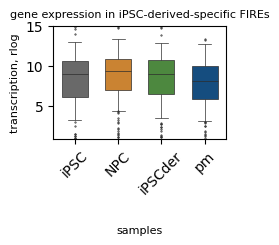

In [89]:

cult_ids=set(expr.index)&set(cult_genes.name)
cult_fires_expr=expr.loc[cult_ids]

my_df=pd.DataFrame()
y1=[]
y3=[]
names=['iPSC','NPC','iPSCder', 'pm']
k=0
l=len(cult_fires_expr)
for i in names:
    y1=y1+list(cult_fires_expr[i])
    y3=y3+[names[k]]*l
    k+=1
    

my_df['transcription, rlog']=y1
my_df['samples']=y3



plt.figure(figsize=(2.5,2.2))
pal=[sc,npc,ipsc,pm]
a=sns.boxplot(data=my_df,x="samples", y='transcription, rlog',palette=pal,
           linewidth=0.5,fliersize=0.5,whis=0.7,width=0.6)
a.set_xticklabels(np.arange(0,18)-0.5)

plt.xticks(np.arange(0,4),names,rotation=45)
plt.tight_layout()
plt.ylim(1,15)
plt.ylabel('transcription, rlog',fontsize=8)
plt.xlabel('\n\nsamples',fontsize=8)
plt.title('gene expression in iPSC-derived-specific FIREs',fontsize=8)

#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/expr_in_cult_spec_fires_sorted_4_cell_types_with_heffel_inf.pdf')




In [92]:
scipy.stats.wilcoxon(cult_fires_expr.iPSCder,cult_fires_expr.pm)

WilcoxonResult(statistic=3518.0, pvalue=1.2430741902143285e-09)

/tmp/ipykernel_287131/513512771.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  neu_fires_expr=expr.loc[neu_ids]
/tmp/ipykernel_287131/513512771.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a=sns.boxplot(data=my_df,x="samples", y='transcription, rlog',palette=pal,
/tmp/ipykernel_287131/513512771.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(np.arange(0,18)-0.5)


Text(0.5, 1.0, 'gene expression in Post-mortem FIREs')

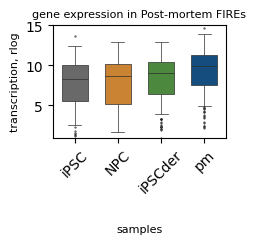

In [93]:
neu_ids=set(expr.index)&set(neu_genes.name)
neu_fires_expr=expr.loc[neu_ids]

my_df=pd.DataFrame()
y1=[]
y3=[]
names=['iPSC','NPC','iPSCder', 'pm']

k=0
l=len(neu_fires_expr)
for i in names:
    y1=y1+list(neu_fires_expr[i])
    y3=y3+[names[k]]*l
    k+=1
    

my_df['transcription, rlog']=y1
my_df['samples']=y3


plt.figure(figsize=(2.5,2.2))
pal=[sc,npc,ipsc,pm]
a=sns.boxplot(data=my_df,x="samples", y='transcription, rlog',palette=pal,
           linewidth=0.5,fliersize=0.5,whis=0.7,width=0.6)
a.set_xticklabels(np.arange(0,18)-0.5)

plt.xticks(np.arange(0,4),names,rotation=45)
plt.tight_layout()
plt.ylim(1,15)
plt.ylabel('transcription, rlog',fontsize=8)
plt.xlabel('\n\nsamples',fontsize=8)
plt.title('gene expression in Post-mortem FIREs',fontsize=8)
#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/expr_in_neu_spec_fires_sorted_4_cell_types_with_heffel_inf.pdf')


In [94]:
scipy.stats.wilcoxon(neu_fires_expr.iPSCder,neu_fires_expr.pm)

WilcoxonResult(statistic=3616.0, pvalue=1.5019026176443323e-15)

In [ ]:
########################################################3

In [2]:
cult_fires_bed=pybedtools.BedTool('/media/anna/Samsung_T5/culture_vs_postmortem/cult_spec_super_fires_with_hef_inf.bed')

In [3]:
neu_fires_bed=pybedtools.BedTool('/media/anna/Samsung_T5/culture_vs_postmortem/neu_spec_super_fires_with_hef_inf.bed')

In [4]:
loops=pd.read_pickle('/media/anna/Samsung_T5/culture_vs_postmortem/loops_clustering_post_mortem_vs_iPSC_derived_merged_Properties_Shorten.pickle')

In [6]:
l=loops[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'cluster', 'is_loop',  'group']]

In [7]:
l.drop_duplicates(inplace=True)

/tmp/ipykernel_203978/3790248990.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  l.drop_duplicates(inplace=True)


In [8]:
l=l.loc[l.is_loop==True]

In [9]:
l1=l[['chrom1','start1','end1','group']]
l2=l[['chrom2','start2','end2','group']]
l1.columns=[0,1,2,3]
l2.columns=[0,1,2,3]
l=pd.concat([l1,l2],axis=0)

In [10]:
l.drop_duplicates(inplace=True)
l.reset_index(inplace=True,drop=True)

In [11]:
l_pm=l.drop_duplicates([0,1,2],keep=False)
l_pm=l_pm.loc[l_pm[3]=='Post-mortem neurons']

l_ipsc=l.drop_duplicates([0,1,2],keep=False)
l_ipsc=l_ipsc.loc[l_ipsc[3]=='iPSC-derived neurons']

In [12]:
l_pm_rest=l.loc[~l.index.isin(l_pm.index)]

In [13]:
len(l)

83372

In [14]:
len(l_pm)

9111

In [15]:
l_pm_bed=pybedtools.BedTool.from_dataframe(l_pm[[0,1,2]])
l_pm_rest_bed=pybedtools.BedTool.from_dataframe(l_pm_rest[[0,1,2]])

In [53]:
not_neu_spec_bed=pybedtools.BedTool.from_dataframe(not_neu_spec)

In [54]:
dh=neu_fires_bed.intersect(l_pm_bed,wa=True).to_dataframe()
len(dh.drop_duplicates())

289

In [55]:
dh=not_neu_spec_bed.intersect(l_pm_bed,wa=True).to_dataframe()
len(dh.drop_duplicates())

2085

In [56]:
dh=neu_fires_bed.intersect(l_pm_rest_bed,wa=True).to_dataframe()
len(dh.drop_duplicates())

530

In [57]:
dh=not_neu_spec_bed.intersect(l_pm_rest_bed,wa=True).to_dataframe()
len(dh.drop_duplicates())

6517

In [58]:
scipy.stats.chi2_contingency([[289,530],[2085,6517]])

(47.84323573954456,
 4.616972504746284e-12,
 1,
 array([[ 206.38000212,  612.61999788],
        [2167.61999788, 6434.38000212]]))

In [406]:
y1=l_pm_bed.intersect(neu_fires_bed,wa=True)
y2=y1.intersect(cult_fires_bed,wa=True)
len(y2)

0

In [407]:
len(y1)

362

In [408]:
y1=l_ipsc_bed.intersect(cult_fires_bed,wa=True)
y2=y1.intersect(neu_fires_bed,wa=True)
len(y2)

0

In [409]:
len(y1)

170

In [412]:
y1=l_ipsc_bed.intersect(neu_fires_bed,wa=True)
len(y1)

129

In [413]:
y1=l_pm_bed.intersect(cult_fires_bed,wa=True)
len(y1)

96

In [430]:
len(l_ipsc_bed.intersect(cult_fires_bed,wa=True))/len(cult_fires_bed)

0.15873015873015872

In [416]:
y1=l_pm_bed.subtract(neu_fires_bed,A=True)
y2=y1.subtract(cult_fires_bed,A=True)

In [417]:
len(y2)

8653

In [420]:
y1=l_ipsc_bed.subtract(cult_fires_bed,A=True)
y2=y1.subtract(neu_fires_bed,A=True)

In [421]:
len(y2)

7194

In [423]:
y1=neu_fires_bed.subtract(l_pm_bed,A=True)
y2=y1.subtract(l_ipsc_bed,A=True)

In [424]:
len(y2)

1164

In [427]:
y1=cult_fires_bed.subtract(l_ipsc_bed,A=True)
y2=y1.subtract(l_pm_bed,A=True)

In [428]:
len(y2)

865

In [431]:
len(l_pm_bed.intersect(neu_fires_bed,wa=True))/len(neu_fires_bed)

0.23737704918032787

In [432]:
l_ipsc_rest=l.loc[~l.index.isin(l_ipsc.index)]

In [159]:
len(l)

83372

In [451]:
l_ipsc_bed=pybedtools.BedTool.from_dataframe(l_ipsc[[0,1,2]])
l_ipsc_rest_bed=pybedtools.BedTool.from_dataframe(l_ipsc_rest[[0,1,2]])

not_cult_spec_bed=pybedtools.BedTool.from_dataframe(not_cult_spec)


In [455]:
y1=cult_fires_bed.intersect(l_ipsc_bed,wa=True).to_dataframe()
len(y1.drop_duplicates())

133

In [453]:
y1=cult_fires_bed.intersect(l_ipsc_rest_bed,wa=True).to_dataframe()
len(y1.drop_duplicates())

391

In [452]:
y1=not_cult_spec_bed.intersect(l_ipsc_bed,wa=True).to_dataframe()
len(y1.drop_duplicates())

1745

In [454]:
y1=not_cult_spec_bed.intersect(l_ipsc_rest_bed,wa=True).to_dataframe()
len(y1.drop_duplicates())

6961

In [456]:
scipy.stats.chi2_contingency([[133,391],[1745,6961]])


(8.363611896608766,
 0.0038280892276071916,
 1,
 array([[ 106.61668472,  417.38331528],
        [1771.38331528, 6934.61668472]]))

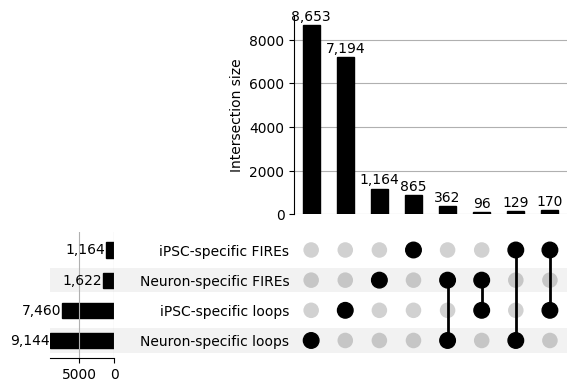

In [460]:
import upsetplot
from upsetplot import from_memberships
from upsetplot import  plot

example = from_memberships(
    [
     ['Neuron-specific loops'],
     ['iPSC-specific loops'],
     ['Neuron-specific FIREs'],
     ['iPSC-specific FIREs'],
     ['Neuron-specific loops', 'Neuron-specific FIREs'],
     ['iPSC-specific loops', 'iPSC-specific FIREs'],
     ['iPSC-specific loops','Neuron-specific FIREs'],
     ['Neuron-specific loops', 'iPSC-specific FIREs'],
     ],
     data=[8653,7194,1164,865,362,170,96,129]
)
plot(example,show_counts="{:,}")
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/upsetplot_loops_fires_overlaps.pdf')